In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

In [44]:


df=pd.read_csv("city_temperature.csv")
df=df[(df["Country"]=="US") & (df["Year"]==2013) ]

city=df["City"].unique()
print(df.isnull().sum())

C:\Users\chikh\AppData\Local\Temp\ipykernel_10716\1824530941.py:1: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("city_temperature.csv")


Region            0
Country           0
State             0
City              0
Month             0
Day               0
Year              0
AvgTemperature    0
dtype: int64


In [45]:

city_id={}
j=1
for i in city:
    city_id[i]=j
    j+=1


In [48]:
df["city_id"] = df["City"].map(city_id)
df.shape

(56057, 9)

<function matplotlib.pyplot.show(close=None, block=None)>

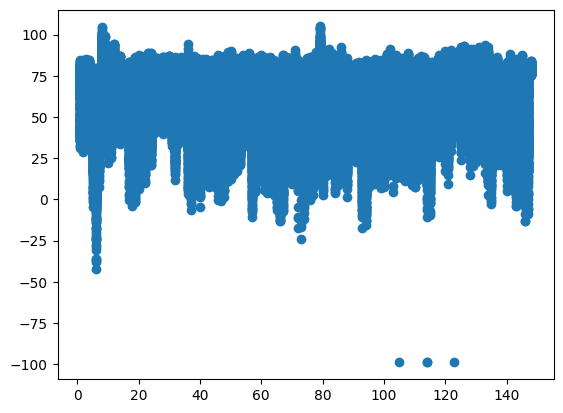

In [47]:
plt.scatter(df['city_id'], df['AvgTemperature'])
plt.show

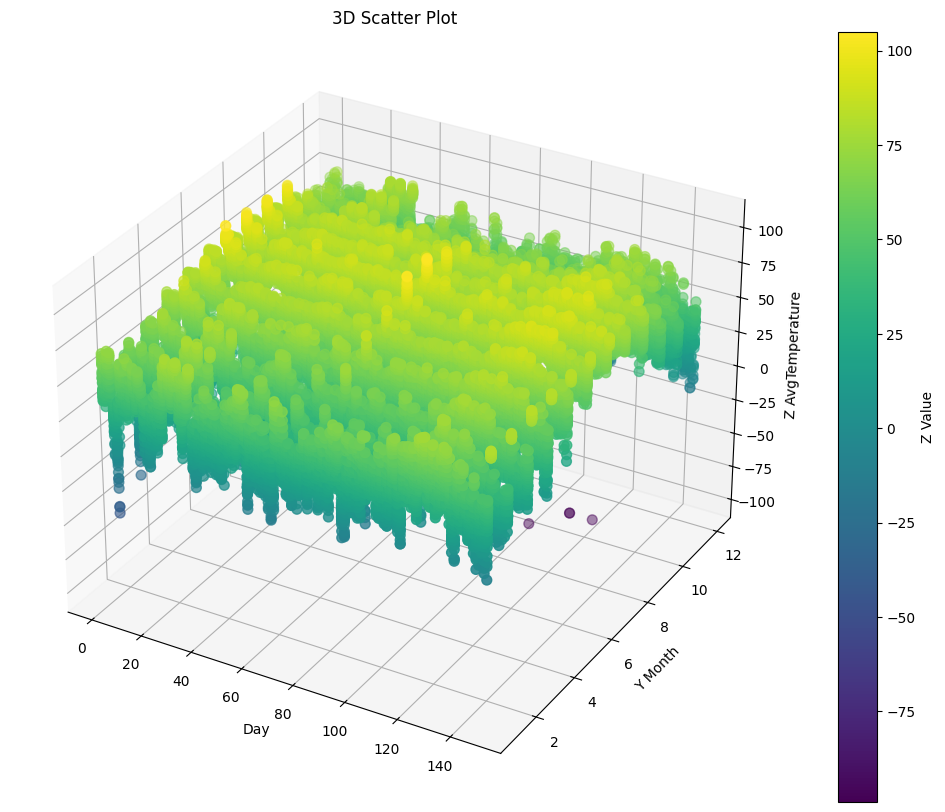

In [50]:
fig = plt.figure(figsize=(15, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot the data
scatter = ax.scatter(df['city_id'], df['Month'], df['AvgTemperature'], 
                     c=df['AvgTemperature'], cmap='viridis', s=50)

# Add labels
ax.set_xlabel('Day')
ax.set_ylabel('Y Month')
ax.set_zlabel('Z AvgTemperature')
ax.set_title('3D Scatter Plot')
plt.colorbar(scatter, ax=ax, label='Z Value')

plt.show()

In [ ]:
X = df[['city_id', 'Month']]  # Features (2 columns)
y = df['AvgTemperature']        # Target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Check the sizes
print(f"Total samples: {len(df)}")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")


Total samples: 56057
Training samples: 44845
Testing samples: 11212

First 5 rows of training features:
         city_id  Month
1718164       25      9
2335494       90     10
2748893      132     10
1660309       22      8
2526513      108      9

First 5 values of training target:
1718164    79.1
2335494    46.5
2748893    75.6
1660309    66.8
2526513    66.6
Name: AvgTemperature, dtype: float64


In [88]:
# Create polynomial features object
poly = PolynomialFeatures(degree=3, include_bias=False)

# Transform the training data
X_train_poly = poly.fit_transform(X_train)

print("Original features (2 columns):", X_train.shape[1])
print("Polynomial features (degree 2):", X_train_poly.shape[1])
print("\nFirst 5 rows of polynomial features:")
print(X_train_poly[:5])
print("\nFeature names:")
print(poly.get_feature_names_out(['city_id', 'Month']))

Original features (2 columns): 2
Polynomial features (degree 2): 9

First 5 rows of polynomial features:
[[2.500000e+01 9.000000e+00 6.250000e+02 2.250000e+02 8.100000e+01
  1.562500e+04 5.625000e+03 2.025000e+03 7.290000e+02]
 [9.000000e+01 1.000000e+01 8.100000e+03 9.000000e+02 1.000000e+02
  7.290000e+05 8.100000e+04 9.000000e+03 1.000000e+03]
 [1.320000e+02 1.000000e+01 1.742400e+04 1.320000e+03 1.000000e+02
  2.299968e+06 1.742400e+05 1.320000e+04 1.000000e+03]
 [2.200000e+01 8.000000e+00 4.840000e+02 1.760000e+02 6.400000e+01
  1.064800e+04 3.872000e+03 1.408000e+03 5.120000e+02]
 [1.080000e+02 9.000000e+00 1.166400e+04 9.720000e+02 8.100000e+01
  1.259712e+06 1.049760e+05 8.748000e+03 7.290000e+02]]

Feature names:
['city_id' 'Month' 'city_id^2' 'city_id Month' 'Month^2' 'city_id^3'
 'city_id^2 Month' 'city_id Month^2' 'Month^3']


In [89]:
# Create and train the model
model = LinearRegression()
model.fit(X_train_poly, y_train)

# See the model parameters
print("Model intercept:", model.intercept_)
print("Model coefficients:", model.coef_)
print("\nCoefficient for each feature:")
for name, coef in zip(poly.get_feature_names_out(['city_id', 'Month']), model.coef_):
    print(f"{name}: {coef:.4f}")

Model intercept: 39.56863981785687
Model coefficients: [-4.08642418e-01  2.67177931e+00  3.57162851e-03  2.93700120e-02
  1.28999054e+00 -8.65646390e-06 -8.42006493e-05 -1.41621446e-03
 -1.26535362e-01]

Coefficient for each feature:
city_id: -0.4086
Month: 2.6718
city_id^2: 0.0036
city_id Month: 0.0294
Month^2: 1.2900
city_id^3: -0.0000
city_id^2 Month: -0.0001
city_id Month^2: -0.0014
Month^3: -0.1265


In [90]:
# Predict on training data
y_train_pred = model.predict(X_train_poly)

# Compare first 5 actual vs predicted
print("First 5 predictions vs actual (training data):")
comparison = pd.DataFrame({
    'Actual': y_train.head(5).values,
    'Predicted': y_train_pred[:5],
    'Difference': y_train.head(5).values - y_train_pred[:5]
})
print(comparison)

First 5 predictions vs actual (training data):
   Actual  Predicted  Difference
0    79.1  71.007348    8.092652
1    46.5  61.458763  -14.958763
2    75.6  62.535054   13.064946
3    66.8  74.211591   -7.411591
4    66.6  69.800610   -3.200610


In [91]:
# Transform test data (using the same poly object)
X_test_poly = poly.transform(X_test)

# Make predictions on test data
y_test_pred = model.predict(X_test_poly)

# Compare first 5 test predictions
print("First 5 predictions vs actual (test data):")
comparison_test = pd.DataFrame({
    'Actual': y_test.head(5).values,
    'Predicted': y_test_pred[:5],
    'Difference': y_test.head(5).values - y_test_pred[:5]
})
print(comparison_test)

First 5 predictions vs actual (test data):
   Actual  Predicted  Difference
0    43.8  37.630921    6.169079
1    78.8  74.410492    4.389508
2    23.1  39.604776  -16.504776
3    76.2  64.086190   12.113810
4    49.9  38.629453   11.270547


In [94]:
from sklearn.metrics import r2_score, mean_squared_error

# Calculate metrics for training
train_r2 = r2_score(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))

# Calculate metrics for testing
test_r2 = r2_score(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("TRAINING SET METRICS:")
print(f"R² Score: {train_r2:.4f}")
print(f"RMSE: {train_rmse:.4f}")

print("\nTESTING SET METRICS:")
print(f"R² Score: {test_r2:.4f}")
print(f"RMSE: {test_rmse:.4f}")

TRAINING SET METRICS:
R² Score: 0.5563
RMSE: 13.0330

TESTING SET METRICS:
R² Score: 0.5667
RMSE: 12.9576
